In [1]:
import numpy as np
import sep

from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib import rcParams

%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]

In [2]:
# read image into standard 2D numpy array 
# get primary HDU
hdul = fits.open('hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits')
data = hdul[0].data

# byteswap for astropy
data = data.byteswap()
data = data.view(data.dtype.newbyteorder('='))

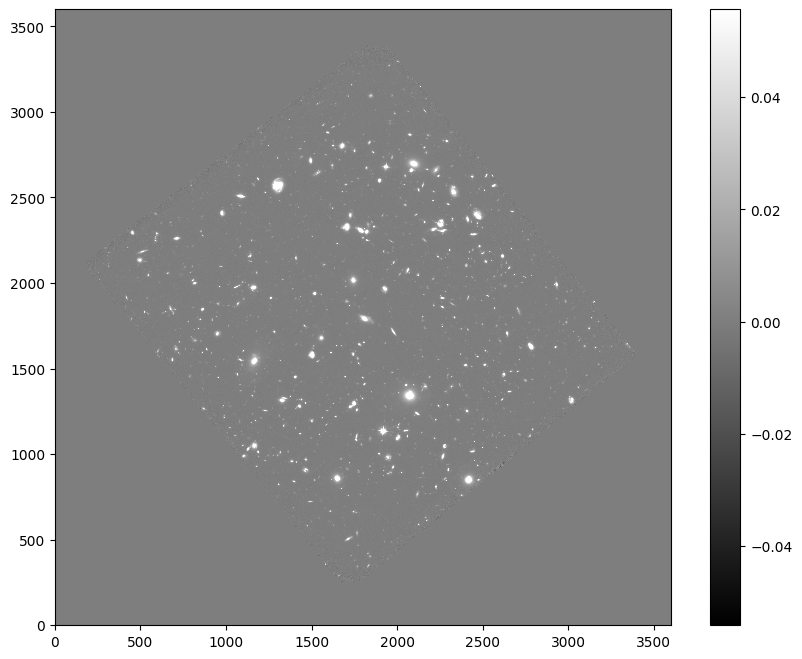

In [3]:
# show image
m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar()
plt.savefig('f105w.png', bbox_inches='tight', facecolor='white')

# Background subtraction

In [4]:
# measure a spatially varying background on the image
bkg = sep.Background(data)

# get a 'global' mean and noise of the image background:
print(bkg.globalback)
print(bkg.globalrms)

0.0
0.0005398219218477607


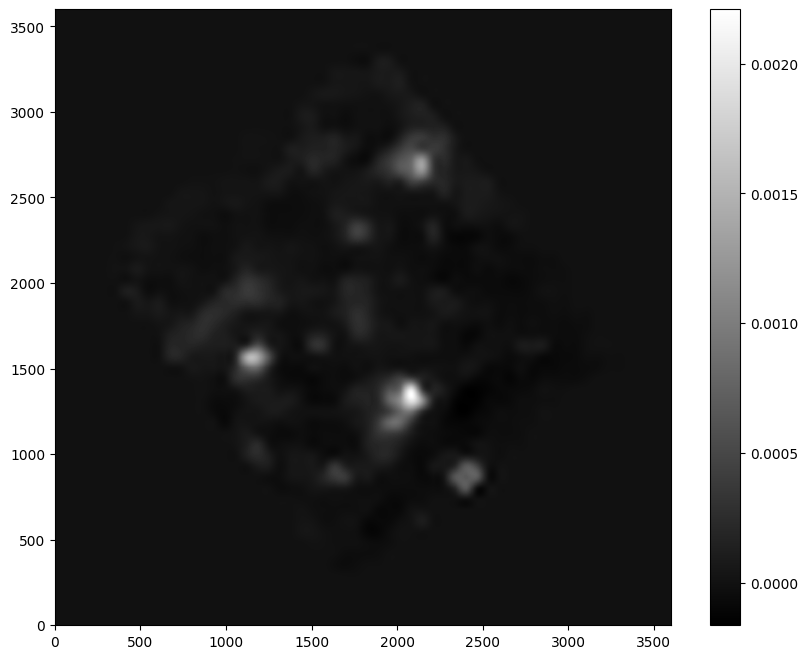

In [5]:
# evaluate background as 2D array, same size as original image
bkg_image = bkg.back()

# show background
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar()
plt.savefig('f105w-background.png', bbox_inches='tight', facecolor='white')

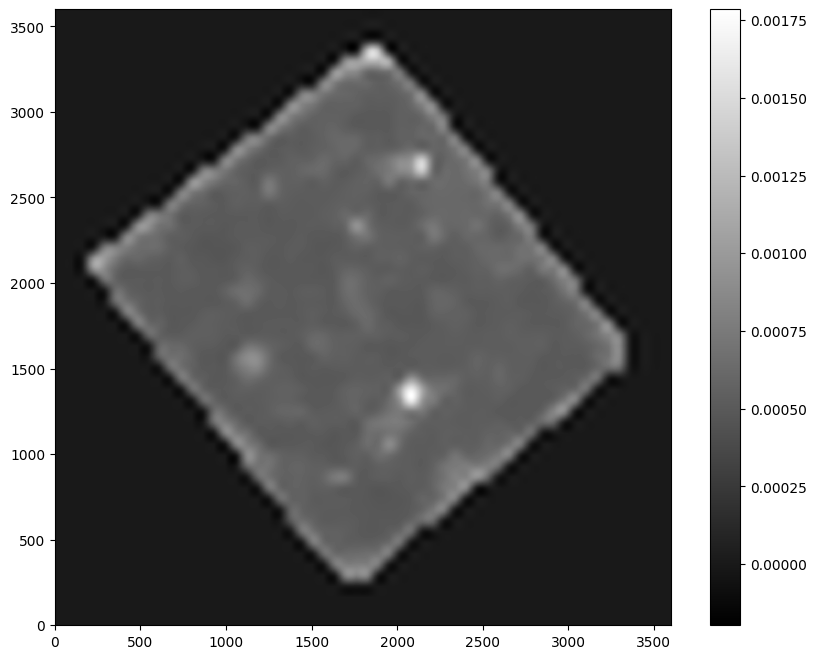

In [6]:
# evaluate background noise as 2D array, same size as original image
bkg_rms = bkg.rms()

# show background noise
plt.imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar()
plt.savefig('f105w-background-noise.png', bbox_inches='tight', facecolor='white')

In [7]:
# subtract background
data_sub = data - bkg

# Object detection

In [8]:
objects = sep.extract(data_sub, 10., err=bkg.globalrms)

In [9]:
# number of objects detected
len(objects)

1545

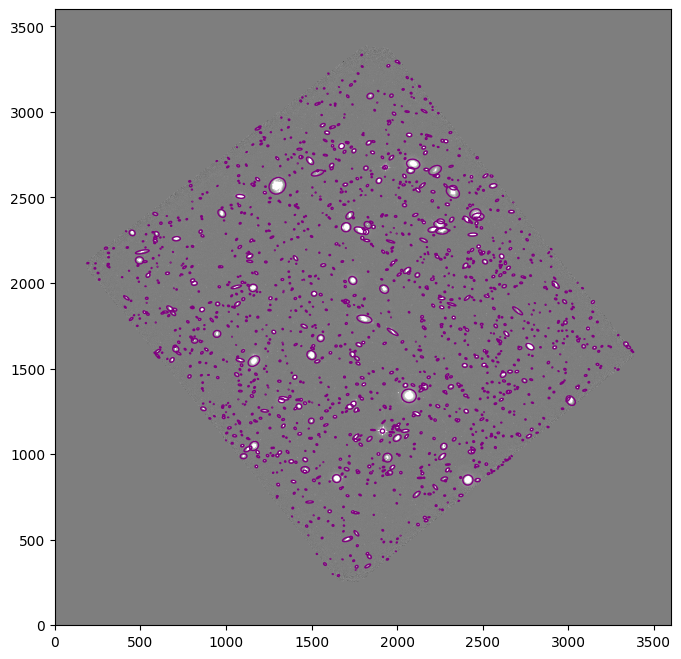

In [10]:
from matplotlib.patches import Ellipse

# plot background subtracted image
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')

# plot an ellipse for each object
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]), width=6*objects['a'][i], height=6*objects['b'][i], angle=objects['theta'][i] * 100. /np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('purple')
    ax.add_artist(e)
    
        

plt.savefig('f105w-objects.png', bbox_inches='tight', facecolor='white')

In [11]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'], 3.0, err=bkg.globalrms, gain=1.0)

# Histogram

-2.0 3.0


Text(0, 0.5, 'number of objects')

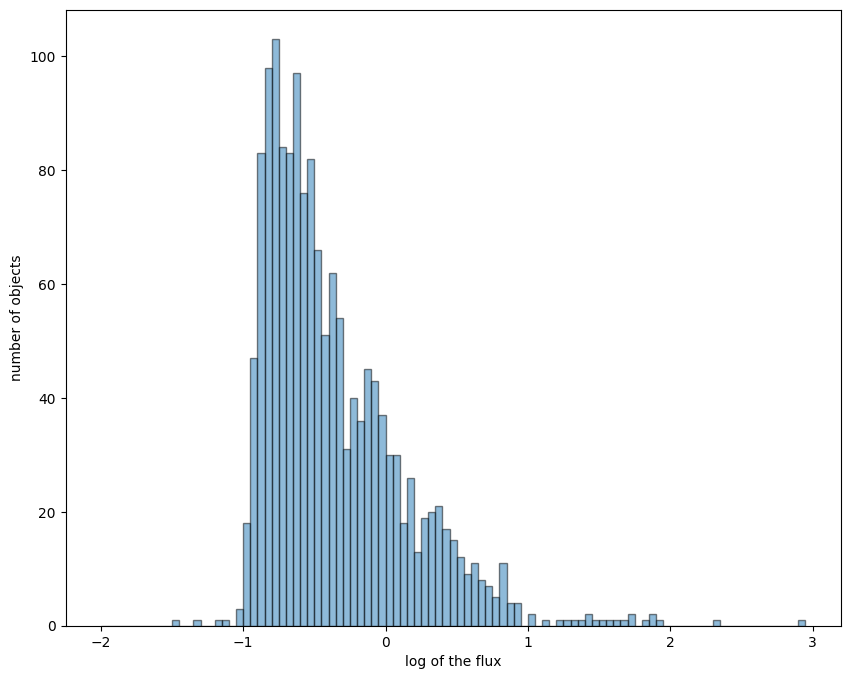

In [12]:
# histogram the flux
width = 0.05
l_flux = np.log10(flux)
histmin = np.floor(min(l_flux))
histmax = np.ceil(max(l_flux))
print(histmin, histmax)
bins = np.arange(histmin, histmax, width)
plt.hist(l_flux, bins=bins, alpha=0.5, edgecolor='black')
plt.xlabel('log of the flux')
plt.ylabel('number of objects')

In [13]:
#mean, median, and standard deviation of the distribution of fluxes
mn_flux = np.mean(flux)
md_flux = np.median(flux)
s_flux = np.std(flux)
print(f'Distribution of Fluxes:\nMean = {mn_flux}\nMedian = {md_flux}\nStandard Deviation = {s_flux}')

Distribution of Fluxes:
Mean = 1.8978623486074184
Median = 0.31320176973007624
Standard Deviation = 21.761805054900137


In [14]:
# outlier, location, standard deviations
outlier = max(flux)
outlier_pos = np.where(flux == outlier) #object 371
outlier_std = (outlier - mn_flux) / s_flux
print(f'The largest outlier has a value of {outlier}.\nIt is {outlier_std} standard deviations from the mean.')

The largest outlier has a value of 805.8583224487305.
It is 36.94364773840735 standard deviations from the mean.


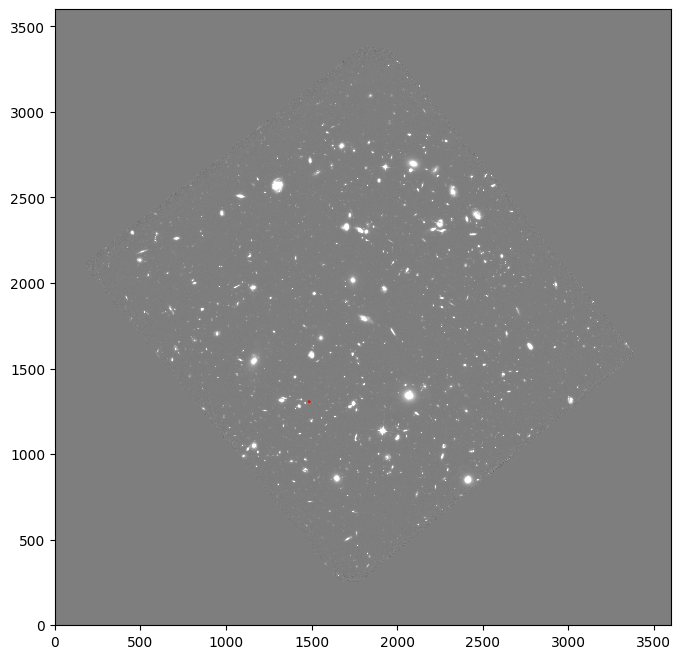

In [15]:
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')

# location of biggest outlier
e = Ellipse(xy=(objects['x'][371], objects['y'][371]), width=6*objects['a'][371], height=6*objects['b'][371], angle=objects['theta'][371] * 100. /np.pi)
e.set_facecolor('none')
e.set_edgecolor('red')
ax.add_artist(e)


# 3-color false image

In [16]:
# read in data
f160w = fits.getdata('hlsp_hudf12_hst_wfc3ir_udfmain_f160w_v1.0_drz.fits')
f125w = fits.getdata('hlsp_hudf12_hst_wfc3ir_udfmain_f125w_v1.0_drz.fits')
f105w = fits.getdata('hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits')

In [17]:
# remove background
med_f160w = np.nanmedian(f160w[f160w<1])
med_f125w = np.nanmedian(f125w[f125w<1])
med_f105w = np.nanmedian(f105w[f105w<1])

f160w = np.asarray(f160w, dtype=np.float32)
f125w = np.asarray(f125w, dtype=np.float32)
f105w = np.asarray(f105w, dtype=np.float32)

bkg_f160w = sep.Background(f160w)
bkg_f125w = sep.Background(f125w)
bkg_f105w = sep.Background(f105w)

In [18]:
# function to rescale data
def rescale_data(data,dmin=0.001,dmax=1):

    datac = np.clip(data,dmin,dmax)
    return (np.log10(datac)-np.log10(dmin))/(np.log10(dmax)-np.log10(dmin))

p_f160w = rescale_data(f160w)
p_f125w = rescale_data(f125w)
p_f105w = rescale_data(f105w)

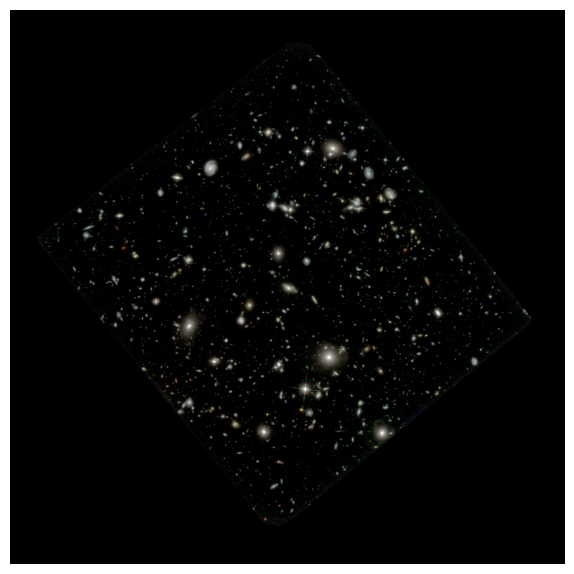

In [19]:
# make RGB stack
rgb = np.stack([p_f160w, p_f125w, p_f105w], axis=-1)

# show data
xsize = rgb.shape[0]
ysize = rgb.shape[1]

f, ax = plt.subplots(1, 1, figsize=(xsize/500., ysize/500.))
ax.axis('off')
ax.imshow(rgb, origin='lower')

plt.imsave('final-rgb-image.png', rgb, origin='lower')